# Experiment: Transformer-based models with PEFT
### In this notebook, we compare two approaches to using transformer-based models for ECG classification:
 1. **HuBERT-ECG fine-tuning**: We take the pretrained HuBERT-ECG model and fine-tune it on our dataset, experimenting with unfreezing different numbers of transformer blocks.
 2. **PatchTST with PEFT**: We train the PatchTST model from scratch, using Parameter-Efficient Fine-Tuning (PEFT) techniques like LoRA and DoRA to reduce the number of trainable parameters.
We evaluate all models on the same validation set and compare their performance to a CNN baseline. The goal is to see if these transformer-based approaches can outperform the CNN while being more parameter-efficient.

In [1]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*Torch was not compiled with flash attention.*"
)

In [2]:
from src.models.hubert_ecg_finetune import HuBERTECGClassifier
import torch

model = HuBERTECGClassifier(size="base", blocks_to_unfreeze=4)

dummy = torch.randn(4, 12, 1000)
with torch.no_grad():
    out = model(dummy)

print(f"Output shape: {out.shape}")  # must be (4, 5)
print("Forward pass OK")


KeyboardInterrupt



In [2]:
# Setup
import sys, os, warnings
sys.path.append('../')
os.environ['TRANSFORMERS_OFFLINE'] = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
warnings.filterwarnings("ignore", category=FutureWarning)

import torch, pandas as pd, matplotlib.pyplot as plt

from src.preprocessing.label_utils  import load_all_labels
from src.preprocessing.dataset      import ECGDataset        # windowed
from src.preprocessing.dataset_full import ECGDatasetFull    # full records
from src.models.hubert_ecg_finetune import HuBERTECGClassifier
from src.models.patchtst_peft       import PatchTSTClassifier
from src.training.train_peft        import run_experiment
from src.utils.config               import CFG

DATA_PATH = CFG['data']['path']
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB")

GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6GB


In [3]:
# Load labels
Y = load_all_labels(
    DATA_PATH + 'ptbxl_database.csv',
    DATA_PATH + 'scp_statements.csv'
)
train_df = Y[Y.strat_fold <  9]
val_df   = Y[Y.strat_fold == 9]
test_df  = Y[Y.strat_fold == 10]


Records with valid labels: 21388
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5235 (24.5%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)


In [4]:
# Build datasets: two versions 
# Windowed (for PatchTST)
train_ds_w = ECGDataset(train_df, DATA_PATH)
val_ds_w   = ECGDataset(val_df,   DATA_PATH)

# Full records (for HuBERT-ECG)
train_ds_f = ECGDatasetFull(train_df, DATA_PATH)
val_ds_f   = ECGDatasetFull(val_df,   DATA_PATH)

print(f"Windowed train: {len(train_ds_w)} samples")
print(f"Full train:     {len(train_ds_f)} samples")

Windowed train: 119588 samples
Full train:     17084 samples


In [6]:
#  Experiment A: HuBERT-ECG 4 blocks
model_A = HuBERTECGClassifier(size=CFG['model']['hubert_size'], blocks_to_unfreeze=4)
auc_A, hist_A = run_experiment(
    model_A, train_ds_f, val_ds_f,
    experiment_name="hubert_ecg_blocks4",
    epochs=CFG['training']['epochs'], lr=CFG['training']['lr_pretrained'],  # lower LR for pretrained model
    batch_size=CFG['training']['batch_size_full'],                           # smaller batch — full records are larger
    save_dir=CFG['paths']['results']
)
del model_A; torch.cuda.empty_cache()


Loading HuBERT-ECG-base...
Loaded.
Unfrozen 64 tensors from last 4 blocks (layers 8–11)
Trainable: 28,551,173 / 93,323,397 (30.6%)

 Experiment : hubert_ecg_blocks4
 Device     : cuda
 Trainable  : 28,551,173  (30.6%)

Epoch 01/3  lr=5.00e-05
  train_loss=0.8513  val_loss=0.8420
  AUC (macro): 0.5163
  F1  (macro): 0.2704
  Per-class AUC:
    NORM : 0.406  ########
    MI   : 0.556  ###########
    STTC : 0.424  ########
    CD   : 0.638  ############
    HYP  : 0.558  ###########
Saved -> D:\GitHub\biosignal-xai\results/hubert_ecg_blocks4\best_adapter/checkpoint.pt
  * Best saved — AUC 0.5163

Epoch 02/3  lr=1.00e-04
  train_loss=0.5989  val_loss=0.5469
  AUC (macro): 0.8438
  F1  (macro): 0.6196
  Per-class AUC:
    NORM : 0.905  ##################
    MI   : 0.842  ################
    STTC : 0.899  #################
    CD   : 0.837  ################
    HYP  : 0.736  ##############
Saved -> D:\GitHub\biosignal-xai\results/hubert_ecg_blocks4\best_adapter/checkpoint.pt
  * Best save

In [7]:
#  Experiment B: HuBERT-ECG 8 blocks
model_B = HuBERTECGClassifier(size=CFG['model']['hubert_size'], blocks_to_unfreeze=8)
auc_B, hist_B = run_experiment(
    model_B, train_ds_f, val_ds_f,
    experiment_name="hubert_ecg_blocks8",
    epochs=CFG['training']['epochs'], lr=CFG['training']['lr_pretrained'],
    batch_size=CFG['training']['batch_size_full'],
    save_dir=CFG['paths']['results']
)
del model_B; torch.cuda.empty_cache()


Loading HuBERT-ECG-base...
Loaded.
Unfrozen 128 tensors from last 8 blocks (layers 4–11)
Trainable: 56,902,661 / 93,323,397 (61.0%)

 Experiment : hubert_ecg_blocks8
 Device     : cuda
 Trainable  : 56,902,661  (61.0%)

Epoch 01/3  lr=5.00e-05
  train_loss=0.8082  val_loss=0.8053
  AUC (macro): 0.5199
  F1  (macro): 0.2423
  Per-class AUC:
    NORM : 0.576  ###########
    MI   : 0.518  ##########
    STTC : 0.434  ########
    CD   : 0.487  #########
    HYP  : 0.584  ###########
Saved -> D:\GitHub\biosignal-xai\results/hubert_ecg_blocks8\best_adapter/checkpoint.pt
  * Best saved — AUC 0.5199

Epoch 02/3  lr=1.00e-04
  train_loss=0.5735  val_loss=0.6355
  AUC (macro): 0.8325
  F1  (macro): 0.5702
  Per-class AUC:
    NORM : 0.859  #################
    MI   : 0.856  #################
    STTC : 0.868  #################
    CD   : 0.843  ################
    HYP  : 0.737  ##############
Saved -> D:\GitHub\biosignal-xai\results/hubert_ecg_blocks8\best_adapter/checkpoint.pt
  * Best save

In [ ]:
# Experiment C: PatchTST + LoRA r=8
model_C = PatchTSTClassifier(rank=8, use_dora=False)
auc_C, hist_C = run_experiment(
    model_C, train_ds_w, val_ds_w,
    experiment_name="patchtst_lora_r8",
    epochs=CFG['training']['epochs'], lr=CFG['training']['lr_peft'],
    batch_size=CFG['training']['batch_size'],
    save_dir=CFG['paths']['results']
)
del model_C; torch.cuda.empty_cache()



 Experiment : patchtst_lora_r8
 Device     : cuda
 Trainable  : 12,288  (2.91%)


In [9]:
# Experiment D: PatchTST + DoRA r=8
model_D = PatchTSTClassifier(rank=8, use_dora=True)
auc_D, hist_D = run_experiment(
    model_D, train_ds_w, val_ds_w,
    experiment_name="patchtst_dora_r8",
    epochs=CFG['training']['epochs'], lr=CFG['training']['lr_peft'],
    batch_size=CFG['training']['batch_size'],
    save_dir=CFG['paths']['results']
)
del model_D; torch.cuda.empty_cache()



 Experiment : patchtst_dora_r8
 Device     : cuda
 Trainable  : 13,056  (3.09%)

Epoch 01/3  lr=1.50e-04
  train_loss=0.8282  val_loss=0.8279
  AUC (macro): 0.5025
  F1  (macro): 0.2776
  Per-class AUC:
    NORM : 0.496  #########
    MI   : 0.521  ##########
    STTC : 0.501  ##########
    CD   : 0.492  #########
    HYP  : 0.503  ##########
  * Best saved — AUC 0.5025


C:\Users\Teodora\miniconda3\envs\biosignal-xai\lib\site-packages\peft\utils\save_and_load.py:243: UserWarning: Could not find a config file in  - will assume that the vocabulary was not modified.
  warnings.warn(



Epoch 02/3  lr=3.00e-04
  train_loss=0.7699  val_loss=0.7417
  AUC (macro): 0.6776
  F1  (macro): 0.2104
  Per-class AUC:
    NORM : 0.720  ##############
    MI   : 0.696  #############
    STTC : 0.691  #############
    CD   : 0.727  ##############
    HYP  : 0.554  ###########
  * Best saved — AUC 0.6776


C:\Users\Teodora\miniconda3\envs\biosignal-xai\lib\site-packages\peft\utils\save_and_load.py:243: UserWarning: Could not find a config file in  - will assume that the vocabulary was not modified.
  warnings.warn(



Epoch 03/3  lr=0.00e+00
  train_loss=0.7199  val_loss=0.6911
  AUC (macro): 0.7424
  F1  (macro): 0.3984
  Per-class AUC:
    NORM : 0.794  ###############
    MI   : 0.752  ###############
    STTC : 0.764  ###############
    CD   : 0.779  ###############
    HYP  : 0.623  ############
  * Best saved — AUC 0.7424

 Done: patchtst_dora_r8
 Best AUC: 0.7424
 Saved to: D:\GitHub\biosignal-xai\results/patchtst_dora_r8/



C:\Users\Teodora\miniconda3\envs\biosignal-xai\lib\site-packages\peft\utils\save_and_load.py:243: UserWarning: Could not find a config file in  - will assume that the vocabulary was not modified.
  warnings.warn(


In [10]:
#  Results table
def best_auc(h): return max(e["auc_macro"] for e in h)
def best_f1(h):  return max(e["f1_macro"]  for e in h)

results = pd.DataFrame([
    {"Model": "CNN (baseline)",          "Strategy": "Full training",    "AUC": 0.9068, "F1": 0.6817},
    {"Model": "HuBERT-ECG-base",         "Strategy": "Unfreeze 4 blocks","AUC": best_auc(hist_A), "F1": best_f1(hist_A)},
    {"Model": "HuBERT-ECG-base",         "Strategy": "Unfreeze 8 blocks","AUC": best_auc(hist_B), "F1": best_f1(hist_B)},
    {"Model": "PatchTST (scratch)",       "Strategy": "LoRA r=8",         "AUC": best_auc(hist_C), "F1": best_f1(hist_C)},
    {"Model": "PatchTST (scratch)",       "Strategy": "DoRA r=8",         "AUC": best_auc(hist_D), "F1": best_f1(hist_D)},
])
results["vs CNN"] = (results["AUC"] - 0.9068).map(
    lambda x: f"+{x:.4f}" if x > 0 else f"{x:.4f}"
)
print(results.to_string(index=False))


             Model          Strategy      AUC       F1  vs CNN
    CNN (baseline)     Full training 0.906800 0.681700  0.0000
   HuBERT-ECG-base Unfreeze 4 blocks 0.844128 0.619610 -0.0627
   HuBERT-ECG-base Unfreeze 8 blocks 0.843764 0.581737 -0.0630
PatchTST (scratch)          LoRA r=8 0.796724 0.559212 -0.1101
PatchTST (scratch)          DoRA r=8 0.742399 0.398372 -0.1644


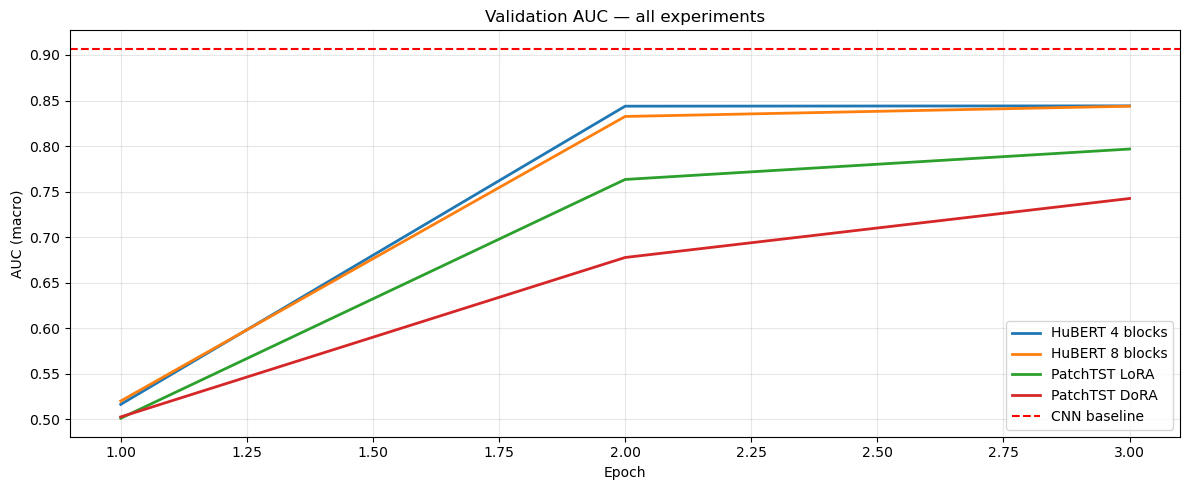

In [11]:
#  Learning curves
fig, ax = plt.subplots(figsize=(12, 5))
for name, hist in [
    ("HuBERT 4 blocks", hist_A),
    ("HuBERT 8 blocks", hist_B),
    ("PatchTST LoRA",   hist_C),
    ("PatchTST DoRA",   hist_D),
]:
    ax.plot([e["epoch"] for e in hist],
            [e["auc_macro"] for e in hist], label=name, linewidth=2)

ax.axhline(y=0.9068, color='red', linestyle='--',
           linewidth=1.5, label='CNN baseline')
ax.set_title("Validation AUC: all experiments")
ax.set_xlabel("Epoch"); ax.set_ylabel("AUC (macro)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CFG['paths']['results'] + 'transformer_comparison.png', dpi=150)
plt.show()